In [1]:
from pathlib import Path
import os
import sys

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / "src" / "utils.py").exists())
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

from src.utils import load_csv, model_path, data_path
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

I0000 00:00:1775853605.999396  825958 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775853606.003978  825958 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775853606.624250  825958 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775853609.942269  825958 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [2]:
# Load in movie tower
movie_tower = tf.keras.models.load_model(model_path("movie_tower.keras"))

# Load in movie data
movies = load_csv("data/movies.csv")
unique_movie_ids = movies['movieId'].unique()

E0000 00:00:1775853616.098978  825958 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
movie_input = np.array(unique_movie_ids)
movie_embeddings = movie_tower.predict(movie_input)

305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 563us/step


In [4]:
tsne = TSNE(n_components=2, perplexity=20, random_state=42)
embeddings_2d = tsne.fit_transform(movie_embeddings)


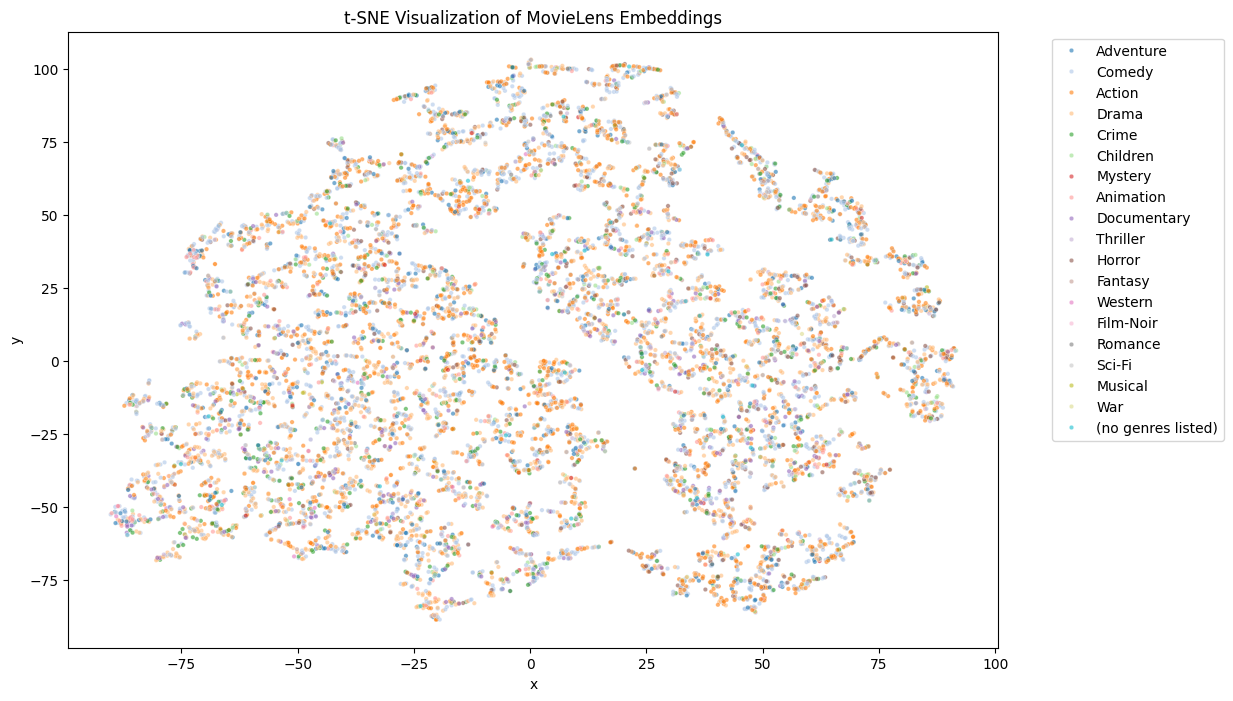

In [5]:
# Create a temporary dataframe for plotting
tsne_df = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'genre': movies['genres'].str.split('|').str[0] # Take the first genre listed
})

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=tsne_df, 
    x='x', y='y', 
    hue='genre', 
    palette='tab20',
 
    alpha=0.6, 
    s=10
)
plt.title('t-SNE Visualization of MovieLens Embeddings')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [6]:
# Make sure movies_df and embeddings_2d have the same number of rows
# (This assumes movies_df is the same one used to generate movie_embeddings)

tsne_df = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'genre': movies['genres'].str.split('|').str[0],
    'title': movies['title'].values  # <--- Add this line!
})

# Now run the plotly code again
import plotly.express as px

fig = px.scatter(
    tsne_df, 
    x='x', 
    y='y', 
    color='genre', 
    hover_data=['title'],
    title="Interactive Movie Clusters"
)
fig.show()

In [ ]:
import umap.umap_ as umap 

ratings = load_csv("data/ratings.csv")

umap_model = umap.UMAP(n_components = 2, n_neighbors = 15, min_dist = 0.1, random_state = 42)

embeddings_2d = umap_model.fit_transform(movie_embeddings)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


KeyError: 'rating'

In [ ]:
umap_df = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'genre': movies['genres'].str.split('|').str[0],
    'title': movies['title'].values
})

fig = px.scatter(
    umap_df,
    x='x',
    y='y',
    color='genre',
    hover_data=['title'],
    title="UMAP Movie Clusters"
)

fig.show()

In [ ]:
ratings = load_csv('data/ratings.csv')

embeddings_2d = umap_model.fit_transform(movie_embeddings)

avg_ratings = ratings.groupby('movieId')['rating'].mean().reset_index()

movies_with_ratings = movies.merge(avg_ratings, on='movieId', how='left')

umap_df = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'genre': movies_with_ratings['genres'].str.split('|').str[0],
    'title': movies_with_ratings['title'],
    'rating': movies_with_ratings['rating']
})

fig = px.scatter(
    umap_df,
    x='x',
    y='y',
    color='rating',
    hover_data=['title'],
    title="UMAP Movie Clusters"
)

fig.show()

umap_df.to_csv(data_path("umap.csv"), index=False)